**TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.**

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

Senoidal de frecuencia $f_0$=$k_0$∗$f_S$/N=$k_0$.Δf
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea $k_0$
 

$N/4$
 
$N/4$+0.25
 
$N/4$+0.5
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  Δf
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

c) Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

Bonus
💎 Calcule la respuesta en frecuencia de los sistemas LTI de la TS2.

**Introducción**

En esta tarea se analiza el efecto de **desparramo espectral** (*spectral leakage*) que aparece al calcular la DFT de una señal senoidal. Se genera una senoidal de frecuencia $f_0$=$k_0$⋅fS/N=$k_0$⋅Δf, con potencia normalizada (varianza unitaria), y se estudia qué ocurre al introducir pequeñas desintonías respecto de Δf.

Como una senoidal de amplitud A tiene potencia media $A^2$/2, para obtener potencia unitaria se eligeunitaria se elige A=$\sqrt{2}.$

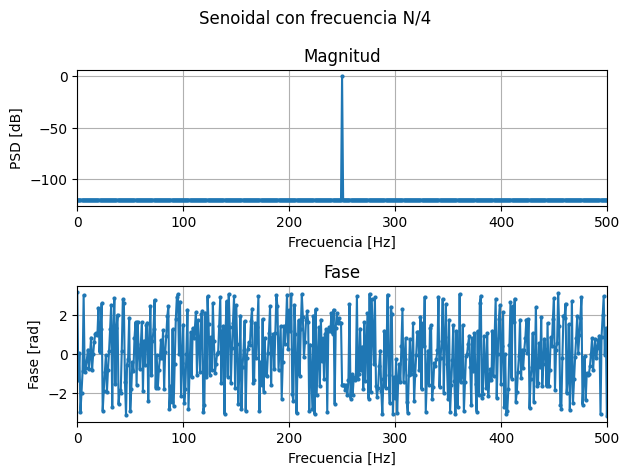

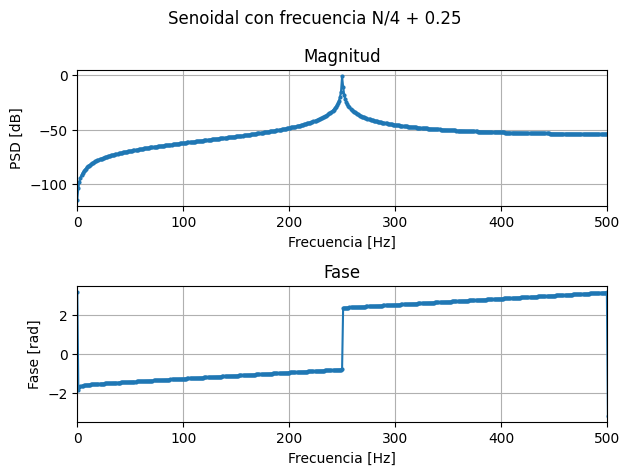

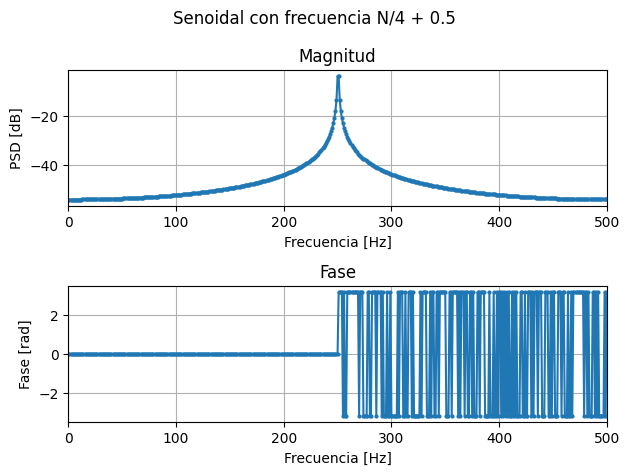

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#%% Parámetros
fs = 1000          # Frecuencia de muestreo [Hz]
N  = 1000          # Cantidad de muestras
ts = 1/fs          # Resolución TEMPORAL (tiempo entre muestras) [s]
df = fs/N          # Resolución ESPECTRAL (frecuencia entre bins) [Hz]
tt = np.arange(N) * ts                 # Eje temporal
freqs = np.arange(0, fs, df)           # Eje de frecuencias

#%% Señal de potencia unitaria

vmax = np.sqrt(2)
dc = 0

#%% Cálculo para los tres casos de desintonía.
# k0 controla cuántos ciclos enteros entran en la ventana de N muestras.
# N/4 -> sintonía exacta (cae justo en un bin). Las fracciones introducen desintonía.
k0_list   = [N/4, N/4 + 0.25, N/4 + 0.5]
titulos   = ["N/4", "N/4 + 0.25", "N/4 + 0.5"]

# Guardo resultados para reutilizar en Parseval y zero padding
señales   = []
espectros = []
psd_db    = []

for k0, titulo in zip(k0_list, titulos):
    f0 = k0 * fs/N                       # Frecuencia en Hz que corresponde a ese k0
    x  = dc + vmax * np.sin(2*np.pi*f0*tt)

    X     = np.fft.fft(x)                # DFT
    Xmod  = (np.abs(X) / N)**2           # |X|^2 normalizado -> PSD (densidad espectral de potencia)
    Xdb   = 10 * np.log10(Xmod * 2 + 1e-12)  # en dB; el *2 junta el lóbulo positivo con su espejo
    Xfase = np.angle(X)

    señales.append(x)
    espectros.append(X)
    psd_db.append(Xdb)

    # Gráfico magnitud + fase
    plt.figure()
    plt.suptitle(f"Senoidal con frecuencia {titulo}")

    plt.subplot(2, 1, 1)
    plt.title("Magnitud")
    plt.plot(freqs, Xdb, marker='o', markersize=2)
    plt.xlim([0, fs/2])
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [dB]')
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.title("Fase")
    plt.plot(freqs, Xfase, marker='o', markersize=2)
    plt.xlim([0, fs/2])
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Fase [rad]')
    plt.grid()

    plt.tight_layout()
    plt.show()

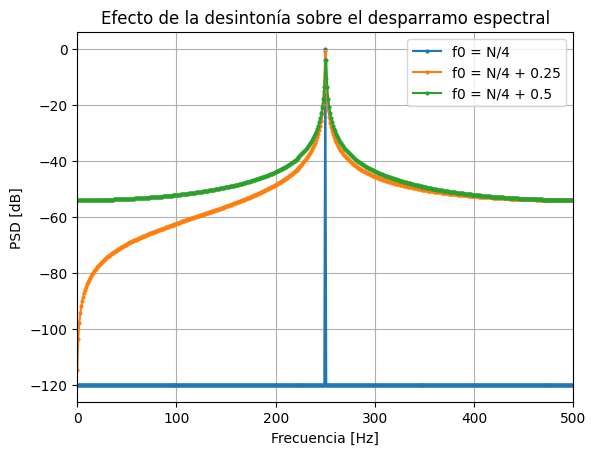

In [2]:
#%% Comparación de las tres PSD superpuestas
plt.figure()
for Xdb, titulo in zip(psd_db, titulos):
    plt.plot(freqs, Xdb, marker='o', markersize=2, label=f"f0 = {titulo}")
plt.xlim([0, fs/2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title("Efecto de la desintonía sobre el desparramo espectral")
plt.grid()
plt.legend()
plt.show()

En el caso sintonizado (k0=N/4), la frecuencia de la senoidal coincide exactamente con un bin de la DFT. Por eso toda la energía se concentra en un único bin y el espectro muestra un pico limpio, con el resto de los bins prácticamente nulos.

Al introducir la desintonía (+0.25 y +0.5), la frecuencia ya no cae sobre ningún bin. La energía, en lugar de concentrarse, se reparte entre los bins vecinos: esto es el desparramo espectral. El pico principal baja de nivel y aparecen lóbulos laterales que decaen lentamente.

El caso más desfavorable es k0=N/4+0.5, porque la frecuencia cae justo en el punto medio entre dos bins. Ahí el desparramo es máximo: la energía se divide casi por igual entre los dos bins centrales y los lóbulos laterales son los más prominentes de los tres casos.

In [3]:
#%% Identidad de Parseval
# Verifico potencia unitaria: potencia en tiempo (varianza) == potencia en frecuencia
print("\n----- Identidad de Parseval -----")
for x, X, titulo in zip(señales, espectros, titulos):
    P_tiempo = np.mean(x**2)
    P_freq   = np.sum(np.abs(X/N)**2)
    print(f"f0 = {titulo:<12} | P_tiempo = {P_tiempo:.4f} | P_freq = {P_freq:.4f}")


----- Identidad de Parseval -----
f0 = N/4          | P_tiempo = 1.0000 | P_freq = 1.0000
f0 = N/4 + 0.25   | P_tiempo = 0.9990 | P_freq = 0.9990
f0 = N/4 + 0.5    | P_tiempo = 1.0000 | P_freq = 1.0000


La identidad de Parseval relaciona la potencia calculada en el dominio temporal con la del dominio frecuencial.

Calculando ambos miembros para los tres casos, la potencia da aproximadamente 1 en todos, confirmando que la normalización con A=$\sqrt{2}$ produce señales de potencia unitaria, y que dicha potencia se conserva entre ambos dominios.

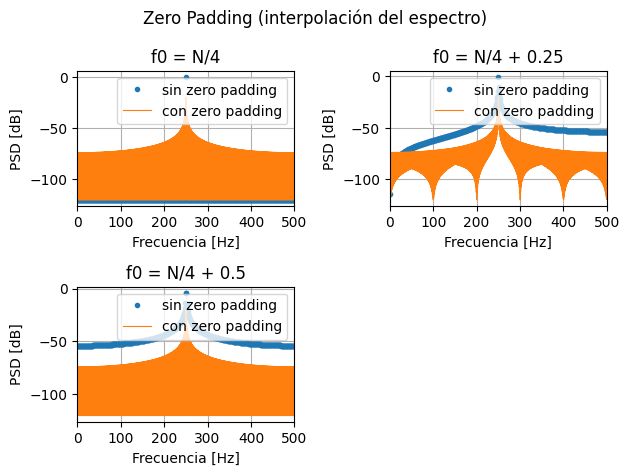

In [4]:
#%% Zero padding (agregar 9*N ceros -> longitud total 10N)
cant_zp = 9
zp = np.zeros(cant_zp * N)

Npad    = N + cant_zp * N           # = 10N
df_pad  = fs / Npad                 # nueva resolución espectral (ficticia)
ff_pad  = np.arange(Npad) * df_pad  # nuevo eje de frecuencias

plt.figure()
plt.suptitle("Zero Padding (interpolación del espectro)")

for i, (x, Xdb, titulo) in enumerate(zip(señales, psd_db, titulos)):
    xp   = np.concatenate((x, zp))           # señal + ceros
    Xp   = np.fft.fft(xp) / Npad             # ¡dividir por Npad, no por N!
    Xpdb = 10 * np.log10(np.abs(Xp)**2 * 2 + 1e-12)

    plt.subplot(2, 2, i+1)
    plt.title(f"f0 = {titulo}")
    plt.plot(freqs,  Xdb,  'o', markersize=3, label="sin zero padding")
    plt.plot(ff_pad, Xpdb, '-', linewidth=0.8, label="con zero padding")
    plt.xlim(0, fs/2)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("PSD [dB]")
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

La técnica consiste en agregar ceros al final de la señal antes de calcular la DFT. Se agregan 9N ceros, llevando la longitud total a 10N. Esto reduce la resolución espectral aparente a Δfpad=$f_S$/(10N), es decir, diez veces más fina.

El zero padding no concentra la energía ni elimina el desparramo. Lo que hace es muestrear más finamente la misma función sinc: al haber diez veces más bins, se ve la forma completa del lóbulo principal y de los lóbulos laterales que antes quedaban "salteados" entre bins.

En términos teóricos, el zero padding es una interpolación del DTFT: rellena con más puntos la curva continua que ya estaba definida, pero no agrega información nueva. La forma del espectro (anchos de lóbulo, niveles) queda determinada por el N real (la cantidad de muestras genuinas de la señal), no por los ceros.

En conclusión el zero padding mejora la visualización del espectro, pero no mejora la resolución espectral verdadera. Para distinguir dos senoidales de frecuencias muy cercanas hace falta aumentar el tiempo de medición N⋅$t_s$.